#                                  timeseris Regresi - RNN

# Load Data

In [15]:
import pandas as pd
import os
import numpy as np

In [16]:

file_name = "microsoft_stock_data"
root_folder = f'timeseris/regresi/rnn/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,3/26/1986,0.057906,0.058437,0.055781,0.056312,22752000
1,3/27/1986,0.058969,0.058969,0.057906,0.057906,16848000
2,3/31/1986,0.058437,0.058969,0.057375,0.058969,12873600
3,4/1/1986,0.057906,0.058437,0.057906,0.058437,11088000
4,4/2/1986,0.058437,0.059500,0.057906,0.057906,27014400


#### Pilih tahun mulai data

In [17]:
# Pastikan kolom Date dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data mulai dari tahun 2000
df = df[df['Date'] >= '1999-01-01']

# (Opsional) urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800


#### tambahkan status green, red, dan netral || DayName

In [18]:
# === Tambahkan kolom nama hari ===
df['Day'] =  df['Date'].dt.day_name()  # bahasa Inggris


df.head()

,Date,Close,High,Low,Open,Volume,Day
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday


#### LabelEncoder

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_Day']            = le.fit_transform(df['Day'])




In [20]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,label_Day
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday,1
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday,3
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday,4
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday,2
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday,0


#### Scaler

In [21]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_Day',
    'Close', 
    'High', 
    'Low',
    'Open',
    'Volume', 
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_Day' saved as scaler_label_Day.pkl
✅ Scaler for 'Close' saved as scaler_Close.pkl
✅ Scaler for 'High' saved as scaler_High.pkl
✅ Scaler for 'Low' saved as scaler_Low.pkl
✅ Scaler for 'Open' saved as scaler_Open.pkl
✅ Scaler for 'Volume' saved as scaler_Volume.pkl

All individual scalers saved successfully!


In [22]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,label_Day
0,1999-01-04,0.019888,0.019737,0.019942,0.018714,0.106426,Monday,0.25
1,1999-01-05,0.021495,0.020511,0.020549,0.019352,0.097822,Tuesday,0.75
2,1999-01-06,0.022883,0.021498,0.022111,0.021500,0.106014,Wednesday,1.00
3,1999-01-07,0.022664,0.021251,0.022553,0.021571,0.075333,Thursday,0.50
4,1999-01-08,0.022482,0.021779,0.022185,0.022257,0.073782,Friday,0.00


#### Mapping label

In [23]:
import json
mapping_dicts = {}

cols = [
    'Day',
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
print(mapping_table)

  feature original_value  label_value
0     Day         Monday         0.25
1     Day        Tuesday         0.75
2     Day      Wednesday         1.00
3     Day       Thursday         0.50
4     Day         Friday         0.00


#### Select Kolom To Trian

In [24]:
col_target = 'Close'
cols = [
    'Date',
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume'
]
df = df[cols].copy()
df.head()

,Date,label_Day,Close,High,Low,Open,Volume
0,1999-01-04,0.25,0.019888,0.019737,0.019942,0.018714,0.106426
1,1999-01-05,0.75,0.021495,0.020511,0.020549,0.019352,0.097822
2,1999-01-06,1.00,0.022883,0.021498,0.022111,0.021500,0.106014
3,1999-01-07,0.50,0.022664,0.021251,0.022553,0.021571,0.075333
4,1999-01-08,0.00,0.022482,0.021779,0.022185,0.022257,0.073782


# Data Load To Train

#### select Future to traian

In [25]:
feature_cols = [
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    #'Volume',
]
target_cols = [col_target]

#### Split data

In [26]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tgl_pembatas = '2020-01-01'
X_train = df[df['Date'] <= tgl_pembatas]
X_test  = df[df['Date'] > tgl_pembatas]
print(f'Train : f{X_train.shape}')
print(f'Test  : f{X_test.shape}')

Train : f(5283, 7)
Test  : f(1457, 7)


#### DataLoader

In [28]:
from data_set import RegressionDatasetTimeSeries
seq_length = 14
slide      = 1
# Buat dataset dengan class kamu
train_dataset = RegressionDatasetTimeSeries(X_train,seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_col=target_cols)
test_dataset  = RegressionDatasetTimeSeries(X_test, seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_col=target_cols)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:6])  # contoh fitur
    print(y[:6])  # contoh label
    break

X shape: torch.Size([32, 14, 5])
y shape: torch.Size([32, 1])
tensor([[[0.2500, 0.0199, 0.0197, 0.0199, 0.0187],
         [0.7500, 0.0215, 0.0205, 0.0205, 0.0194],
         [1.0000, 0.0229, 0.0215, 0.0221, 0.0215],
         [0.5000, 0.0227, 0.0213, 0.0226, 0.0216],
         [0.0000, 0.0225, 0.0218, 0.0222, 0.0223],
         [0.2500, 0.0218, 0.0213, 0.0214, 0.0219],
         [0.7500, 0.0202, 0.0205, 0.0204, 0.0211],
         [1.0000, 0.0207, 0.0204, 0.0189, 0.0177],
         [0.5000, 0.0201, 0.0198, 0.0206, 0.0203],
         [0.0000, 0.0224, 0.0211, 0.0205, 0.0197],
         [0.7500, 0.0242, 0.0234, 0.0233, 0.0220],
         [1.0000, 0.0262, 0.0261, 0.0267, 0.0264],
         [0.5000, 0.0249, 0.0248, 0.0253, 0.0250],
         [0.0000, 0.0243, 0.0240, 0.0246, 0.0232]],

        [[0.7500, 0.0215, 0.0205, 0.0205, 0.0194],
         [1.0000, 0.0229, 0.0215, 0.0221, 0.0215],
         [0.5000, 0.0227, 0.0213, 0.0226, 0.0216],
         [0.0000, 0.0225, 0.0218, 0.0222, 0.0223],
         [0.2500, 

# Config

In [29]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "threshold"      : 0.5,
    "input_size"     : len(test_dataset[0][0][0]),
    "hidden_size"    : 32,
    "num_layers"     : 1,
    "output_size"    : 1,
    "dropout"        : 0.1,
    "bidirectional"  : True,
    "early_stop_patience" : 30,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(bidirectional=True, col_target=Close, dropout=0.1, early_stop_patience=30, feature_cols=['label_Day', 'Close', 'High', 'Low', 'Open'], hidden_size=32, input_size=5, num_layers=1, output_size=1, threshold=0.5)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [39]:
from class_lib import RNN_Pure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False
model = RNN_Pure(
    input_size=config.input_size, 
    hidden_size=config.hidden_size, 
    num_layers=config.num_layers, 
    output_size=config.output_size, 
    dropout=config.dropout, 
    bidirectional=config.bidirectional
).to(device)

#Criterion
criterion =nn.MSELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.6)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

/home/arindyproject/miniconda3/envs/ai2/lib/python3.8/site-packages/torch/nn/modules/rnn.py:47: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1079.73it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  0.0054 │  0.2792 │
│ MAE    │  0.0530 │  0.4945 │
│ RMSE   │  0.0734 │  0.5274 │
│ R2     │ -1.0599 │ -7.5749 │
└────────┴─────────┴─────────┘

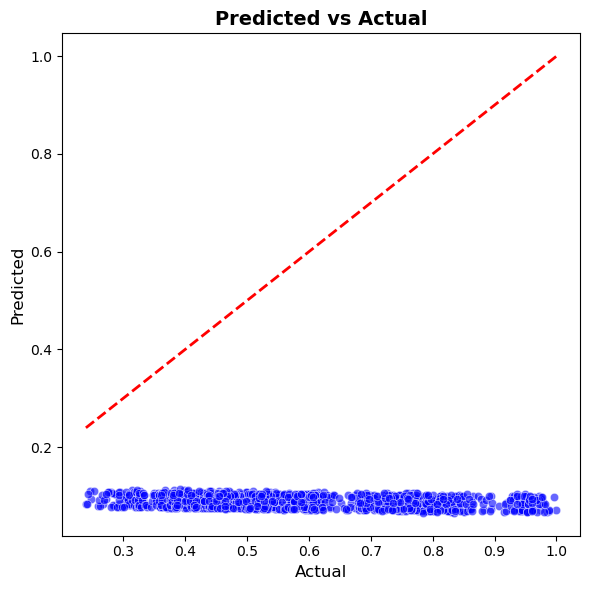


Epoch     1
Train_cost  = 0.0054 | Test_cost  = 0.2792 | Train_score = -1.0599 | Test_score = -7.5749 |
==> EarlyStop patience =  1 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1055.86it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  0.0028 │  0.2722 │
│ MAE    │  0.0360 │  0.4884 │
│ RMSE   │  0.0524 │  0.5207 │
│ R2     │ -0.0520 │ -7.3598 │
└────────┴─────────┴─────────┘

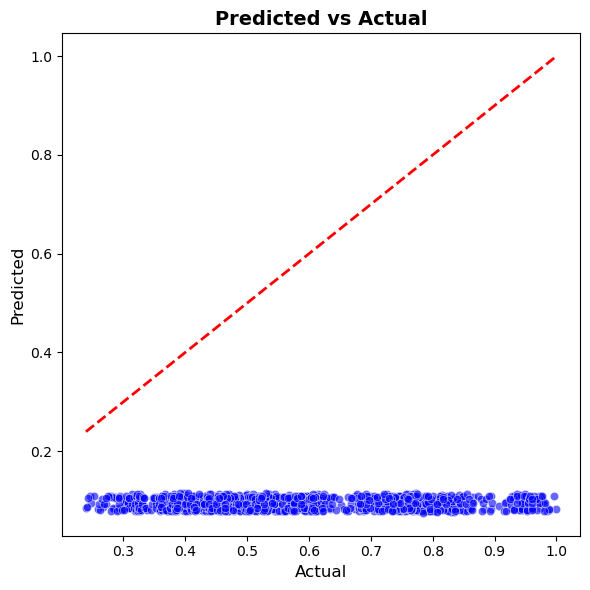


Epoch     2
Train_cost  = 0.0028 | Test_cost  = 0.2722 | Train_score = -0.0520 | Test_score = -7.3598 |
==> EarlyStop patience =  2 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1068.75it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  0.0027 │  0.2642 │
│ MAE    │  0.0351 │  0.4811 │
│ RMSE   │  0.0513 │  0.5130 │
│ R2     │ -0.0074 │ -7.1137 │
└────────┴─────────┴─────────┘

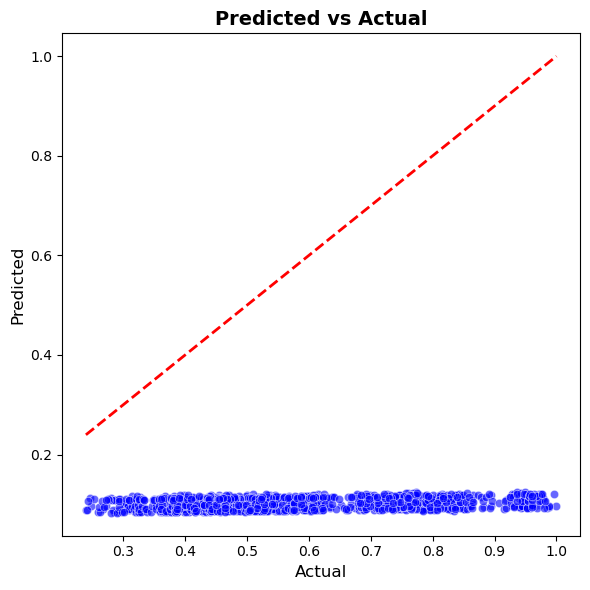


Epoch     3
Train_cost  = 0.0027 | Test_cost  = 0.2642 | Train_score = -0.0074 | Test_score = -7.1137 |
==> EarlyStop patience =  3 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1185.20it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0026 │  0.2563 │
│ MAE    │ 0.0345 │  0.4739 │
│ RMSE   │ 0.0505 │  0.5054 │
│ R2     │ 0.0257 │ -6.8732 │
└────────┴────────┴─────────┘

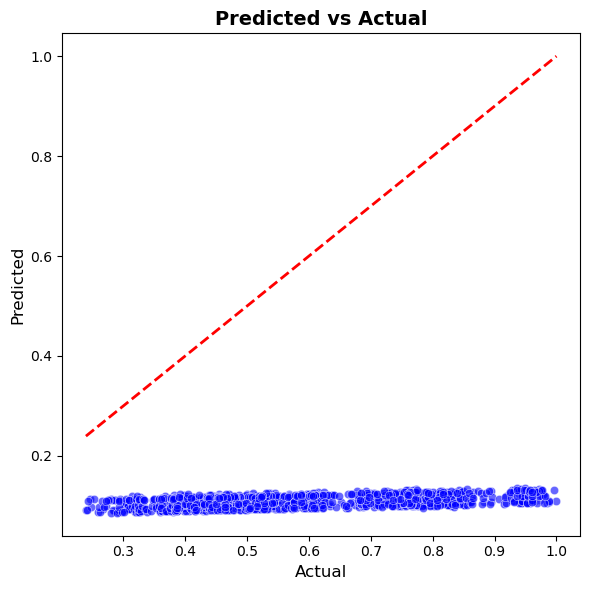


Epoch     4
Train_cost  = 0.0026 | Test_cost  = 0.2563 | Train_score = 0.0257 | Test_score = -6.8732 |
==> EarlyStop patience =  4 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1230.04it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0025 │  0.2487 │
│ MAE    │ 0.0339 │  0.4667 │
│ RMSE   │ 0.0496 │  0.4978 │
│ R2     │ 0.0574 │ -6.6385 │
└────────┴────────┴─────────┘

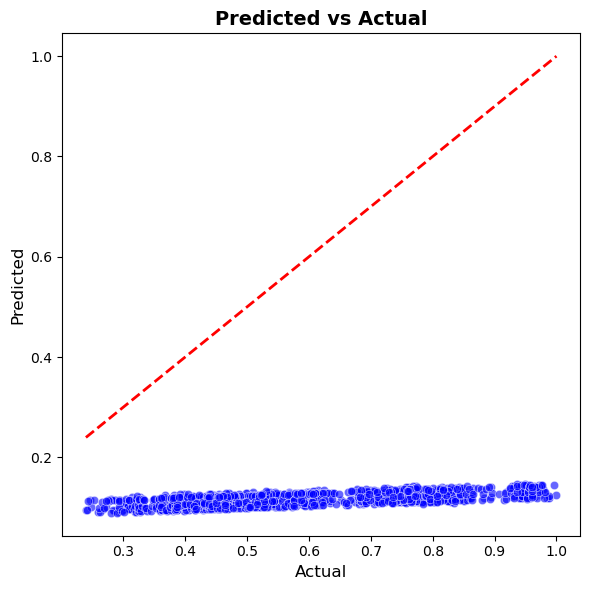


Epoch     5
Train_cost  = 0.0025 | Test_cost  = 0.2487 | Train_score = 0.0574 | Test_score = -6.6385 |
==> EarlyStop patience =  5 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1290.56it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0024 │  0.2412 │
│ MAE    │ 0.0333 │  0.4596 │
│ RMSE   │ 0.0488 │  0.4902 │
│ R2     │ 0.0879 │ -6.4096 │
└────────┴────────┴─────────┘

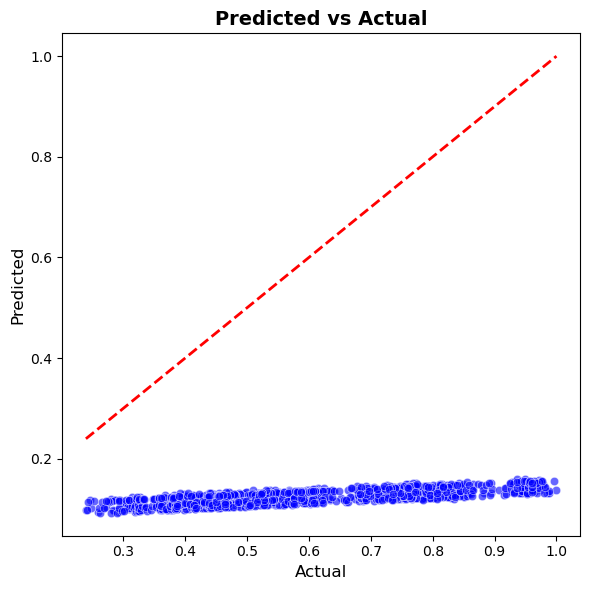


Epoch     6
Train_cost  = 0.0024 | Test_cost  = 0.2412 | Train_score = 0.0879 | Test_score = -6.4096 |
==> EarlyStop patience =  6 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1277.94it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0023 │  0.2340 │
│ MAE    │ 0.0327 │  0.4526 │
│ RMSE   │ 0.0480 │  0.4828 │
│ R2     │ 0.1173 │ -6.1860 │
└────────┴────────┴─────────┘

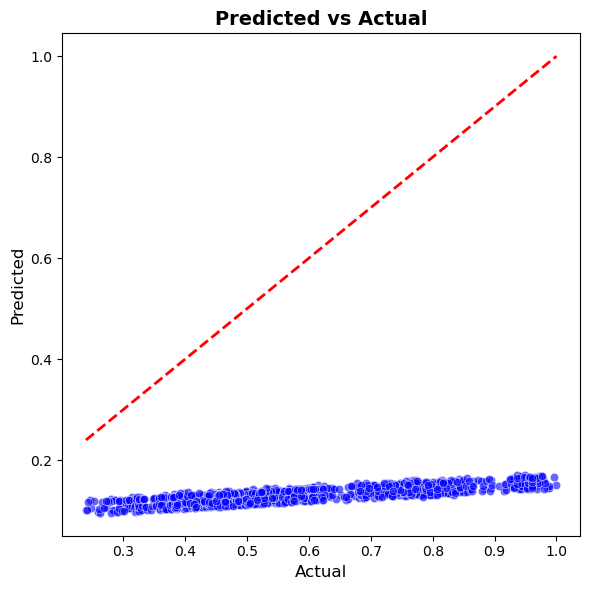


Epoch     7
Train_cost  = 0.0023 | Test_cost  = 0.2340 | Train_score = 0.1173 | Test_score = -6.1860 |
==> EarlyStop patience =  7 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1265.72it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0023 │  0.2269 │
│ MAE    │ 0.0321 │  0.4456 │
│ RMSE   │ 0.0472 │  0.4754 │
│ R2     │ 0.1457 │ -5.9678 │
└────────┴────────┴─────────┘

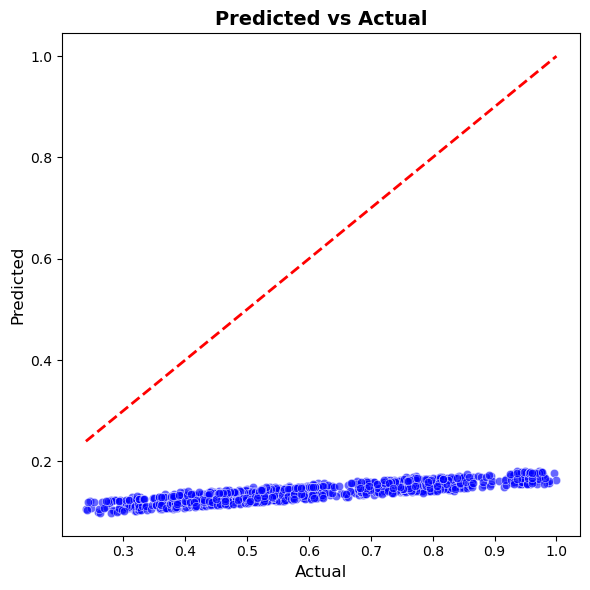


Epoch     8
Train_cost  = 0.0023 | Test_cost  = 0.2269 | Train_score = 0.1457 | Test_score = -5.9678 |
==> EarlyStop patience =  8 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1184.23it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0022 │  0.2199 │
│ MAE    │ 0.0316 │  0.4387 │
│ RMSE   │ 0.0465 │  0.4681 │
│ R2     │ 0.1733 │ -5.7547 │
└────────┴────────┴─────────┘

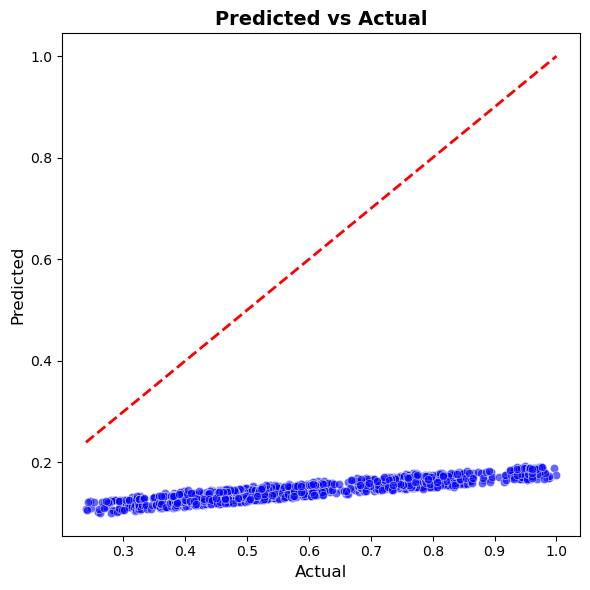


Epoch     9
Train_cost  = 0.0022 | Test_cost  = 0.2199 | Train_score = 0.1733 | Test_score = -5.7547 |
==> EarlyStop patience =  9 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1005.23it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0021 │  0.2131 │
│ MAE    │ 0.0311 │  0.4318 │
│ RMSE   │ 0.0457 │  0.4608 │
│ R2     │ 0.1999 │ -5.5466 │
└────────┴────────┴─────────┘

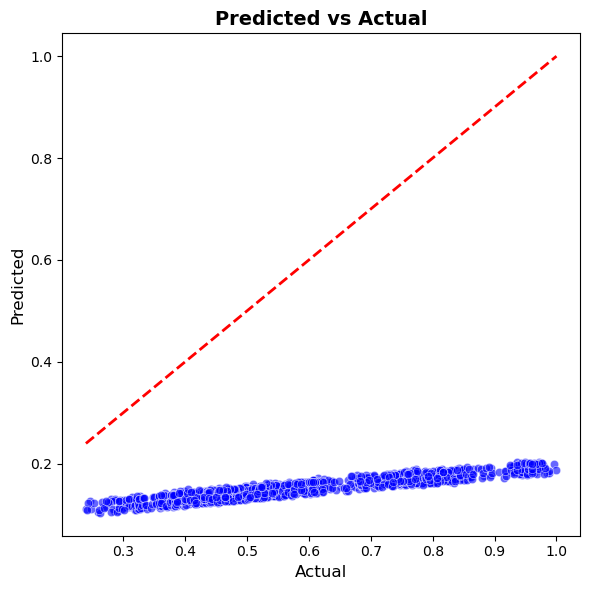


Epoch    10
Train_cost  = 0.0021 | Test_cost  = 0.2131 | Train_score = 0.1999 | Test_score = -5.5466 |
==> EarlyStop patience = 10 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1232.15it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0020 │  0.2065 │
│ MAE    │ 0.0305 │  0.4250 │
│ RMSE   │ 0.0450 │  0.4536 │
│ R2     │ 0.2258 │ -5.3432 │
└────────┴────────┴─────────┘

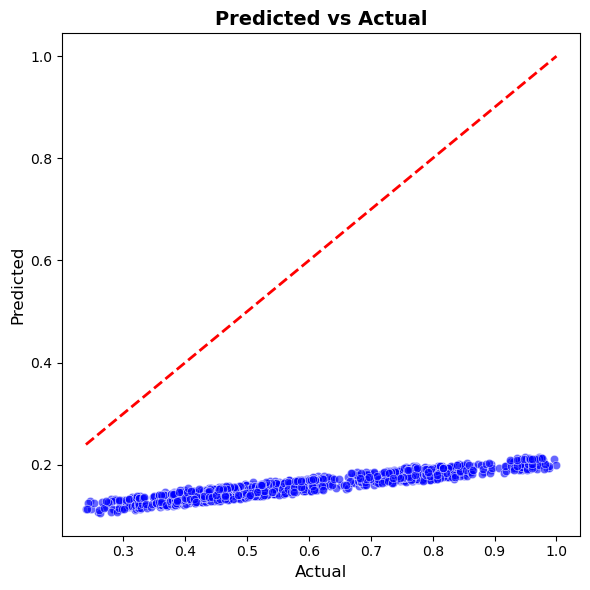


Epoch    11
Train_cost  = 0.0020 | Test_cost  = 0.2065 | Train_score = 0.2258 | Test_score = -5.3432 |
==> EarlyStop patience = 11 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1228.04it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0020 │  0.2001 │
│ MAE    │ 0.0300 │  0.4182 │
│ RMSE   │ 0.0442 │  0.4464 │
│ R2     │ 0.2510 │ -5.1446 │
└────────┴────────┴─────────┘

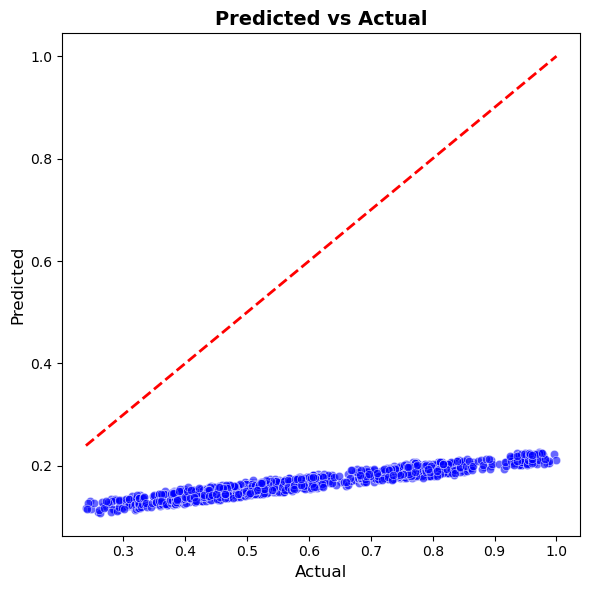


Epoch    12
Train_cost  = 0.0020 | Test_cost  = 0.2001 | Train_score = 0.2510 | Test_score = -5.1446 |
==> EarlyStop patience = 12 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1099.56it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0019 │  0.1937 │
│ MAE    │ 0.0295 │  0.4115 │
│ RMSE   │ 0.0435 │  0.4393 │
│ R2     │ 0.2754 │ -4.9506 │
└────────┴────────┴─────────┘

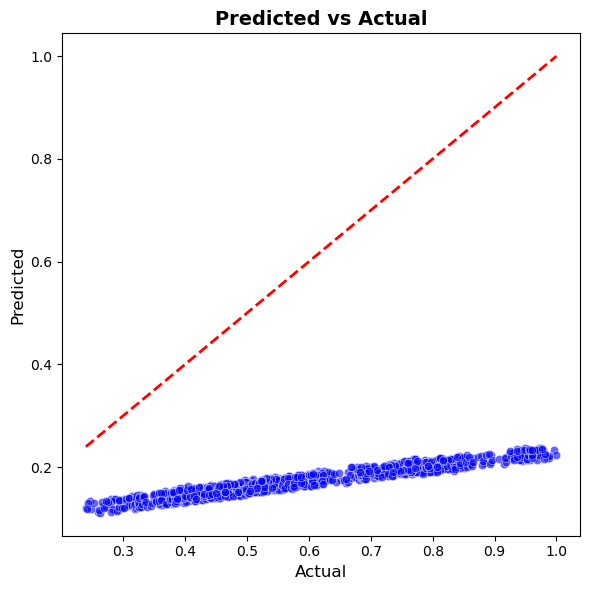


Epoch    13
Train_cost  = 0.0019 | Test_cost  = 0.1937 | Train_score = 0.2754 | Test_score = -4.9506 |
==> EarlyStop patience = 13 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1147.64it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0018 │  0.1876 │
│ MAE    │ 0.0290 │  0.4048 │
│ RMSE   │ 0.0428 │  0.4323 │
│ R2     │ 0.2992 │ -4.7610 │
└────────┴────────┴─────────┘

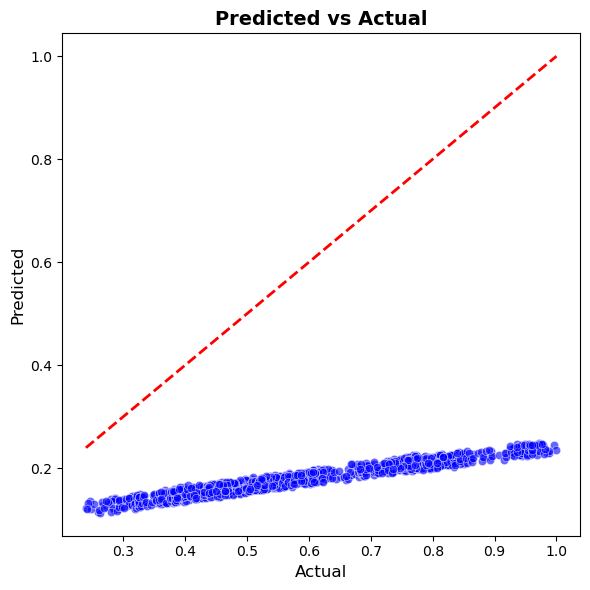


Epoch    14
Train_cost  = 0.0018 | Test_cost  = 0.1876 | Train_score = 0.2992 | Test_score = -4.7610 |
==> EarlyStop patience = 14 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1135.46it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0018 │  0.1815 │
│ MAE    │ 0.0285 │  0.3981 │
│ RMSE   │ 0.0421 │  0.4253 │
│ R2     │ 0.3224 │ -4.5758 │
└────────┴────────┴─────────┘

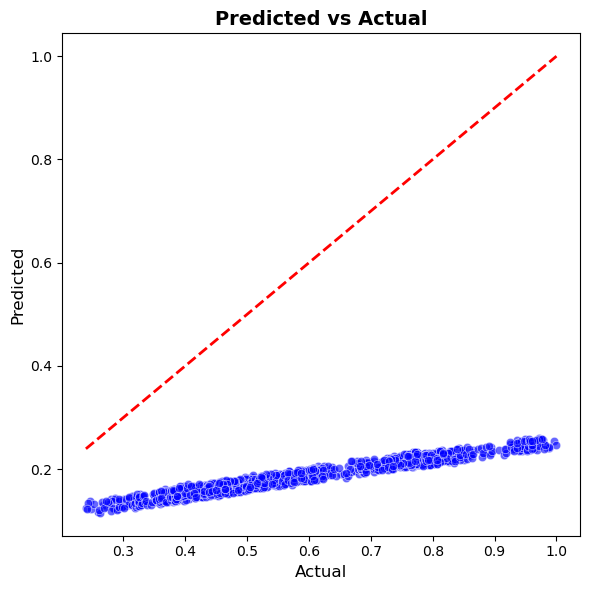


Epoch    15
Train_cost  = 0.0018 | Test_cost  = 0.1815 | Train_score = 0.3224 | Test_score = -4.5758 |
==> EarlyStop patience = 15 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1086.32it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0017 │  0.1757 │
│ MAE    │ 0.0281 │  0.3916 │
│ RMSE   │ 0.0414 │  0.4183 │
│ R2     │ 0.3450 │ -4.3949 │
└────────┴────────┴─────────┘

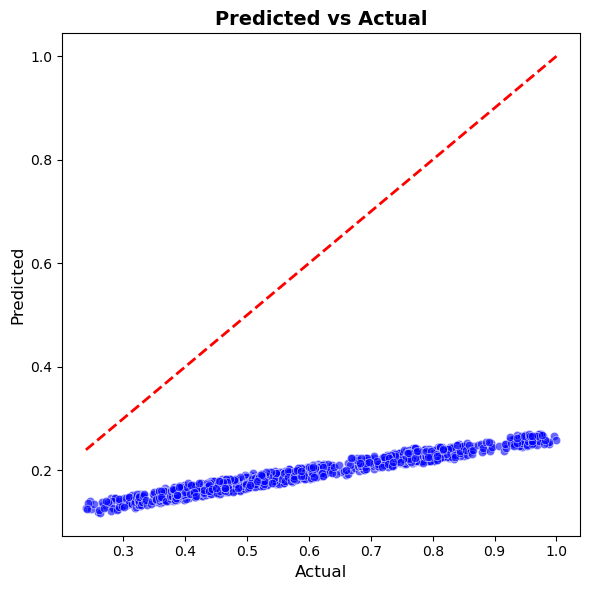


Epoch    16
Train_cost  = 0.0017 | Test_cost  = 0.1757 | Train_score = 0.3450 | Test_score = -4.3949 |
==> EarlyStop patience = 16 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1145.86it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0017 │  0.1699 │
│ MAE    │ 0.0276 │  0.3850 │
│ RMSE   │ 0.0407 │  0.4114 │
│ R2     │ 0.3670 │ -4.2182 │
└────────┴────────┴─────────┘

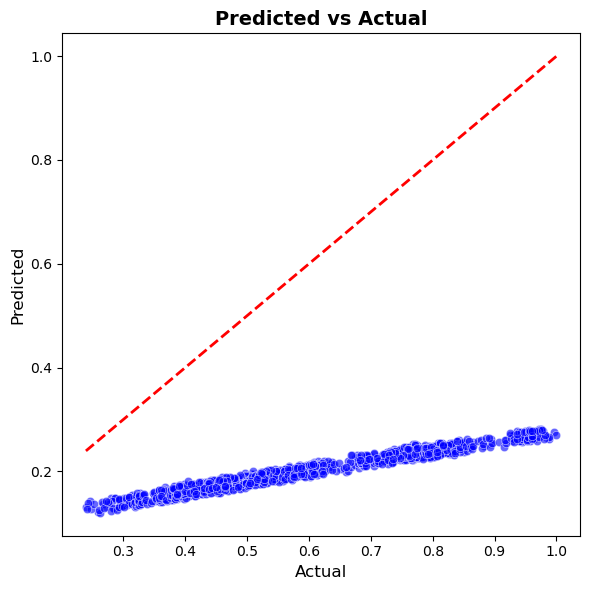


Epoch    17
Train_cost  = 0.0017 | Test_cost  = 0.1699 | Train_score = 0.3670 | Test_score = -4.2182 |
==> EarlyStop patience = 17 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1149.79it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0016 │  0.1643 │
│ MAE    │ 0.0271 │  0.3785 │
│ RMSE   │ 0.0400 │  0.4046 │
│ R2     │ 0.3884 │ -4.0456 │
└────────┴────────┴─────────┘

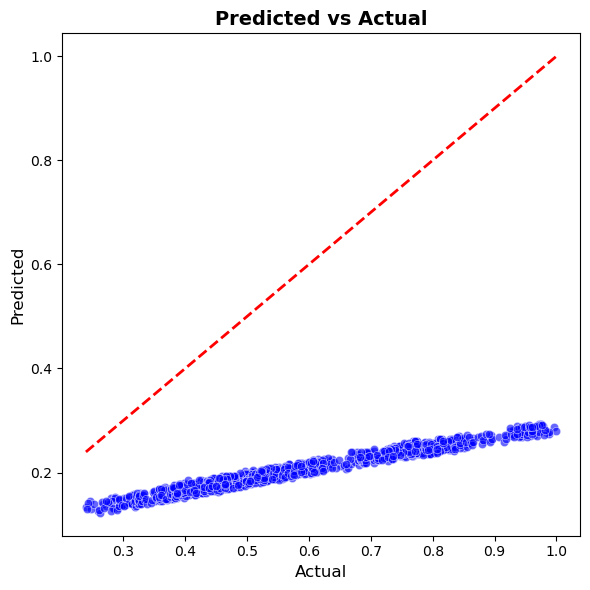


Epoch    18
Train_cost  = 0.0016 | Test_cost  = 0.1643 | Train_score = 0.3884 | Test_score = -4.0456 |
==> EarlyStop patience = 18 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 962.87it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0016 │  0.1588 │
│ MAE    │ 0.0266 │  0.3720 │
│ RMSE   │ 0.0393 │  0.3977 │
│ R2     │ 0.4094 │ -3.8770 │
└────────┴────────┴─────────┘

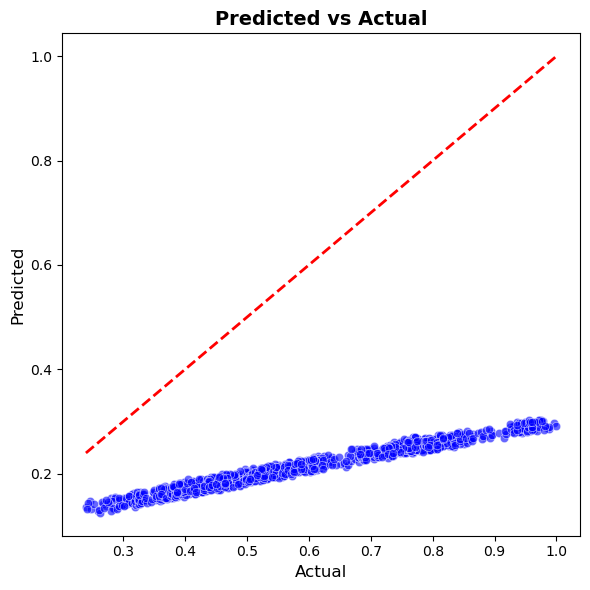


Epoch    19
Train_cost  = 0.0016 | Test_cost  = 0.1588 | Train_score = 0.4094 | Test_score = -3.8770 |
==> EarlyStop patience = 19 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1197.00it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0015 │  0.1534 │
│ MAE    │ 0.0262 │  0.3656 │
│ RMSE   │ 0.0386 │  0.3910 │
│ R2     │ 0.4298 │ -3.7124 │
└────────┴────────┴─────────┘

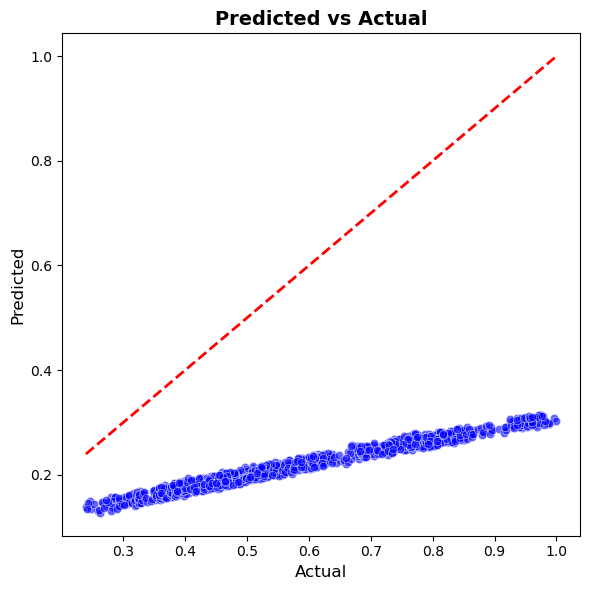


Epoch    20
Train_cost  = 0.0015 | Test_cost  = 0.1534 | Train_score = 0.4298 | Test_score = -3.7124 |


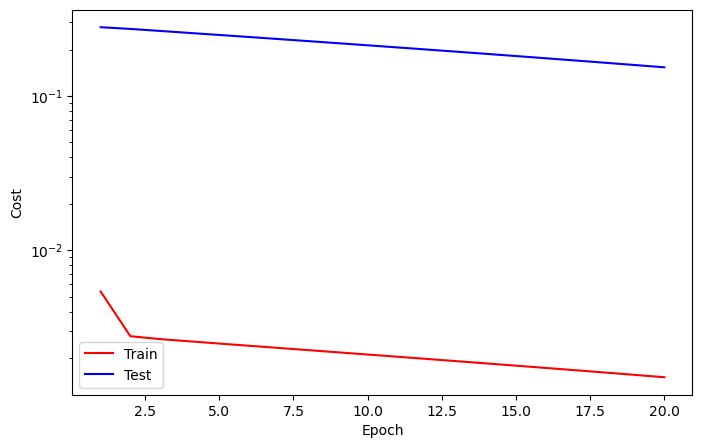

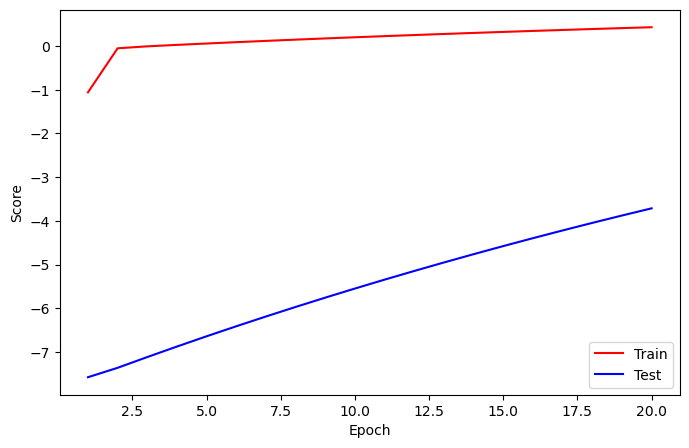

==> EarlyStop patience = 20 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1255.62it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0014 │  0.1482 │
│ MAE    │ 0.0257 │  0.3592 │
│ RMSE   │ 0.0379 │  0.3842 │
│ R2     │ 0.4497 │ -3.5518 │
└────────┴────────┴─────────┘

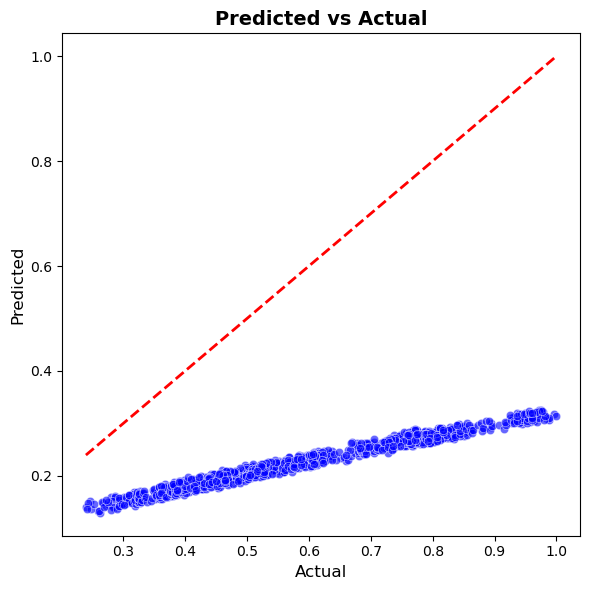


Epoch    21
Train_cost  = 0.0014 | Test_cost  = 0.1482 | Train_score = 0.4497 | Test_score = -3.5518 |
==> EarlyStop patience = 21 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 22 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1140.65it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0014 │  0.1431 │
│ MAE    │ 0.0253 │  0.3529 │
│ RMSE   │ 0.0372 │  0.3776 │
│ R2     │ 0.4691 │ -3.3950 │
└────────┴────────┴─────────┘

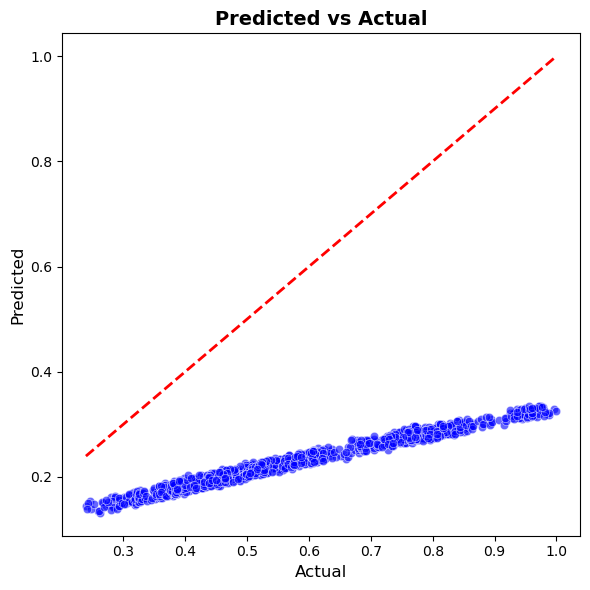


Epoch    22
Train_cost  = 0.0014 | Test_cost  = 0.1431 | Train_score = 0.4691 | Test_score = -3.3950 |
==> EarlyStop patience = 22 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 23 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1069.90it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0013 │  0.1381 │
│ MAE    │ 0.0248 │  0.3466 │
│ RMSE   │ 0.0366 │  0.3709 │
│ R2     │ 0.4881 │ -3.2419 │
└────────┴────────┴─────────┘

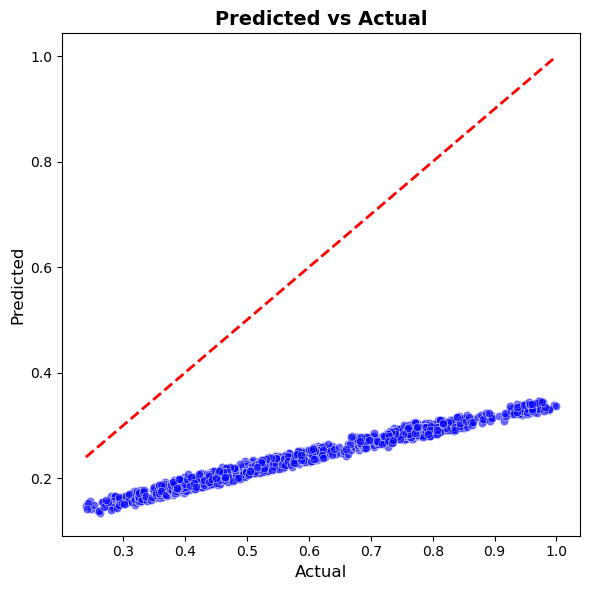


Epoch    23
Train_cost  = 0.0013 | Test_cost  = 0.1381 | Train_score = 0.4881 | Test_score = -3.2419 |
==> EarlyStop patience = 23 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 24 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1196.68it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0013 │  0.1333 │
│ MAE    │ 0.0244 │  0.3403 │
│ RMSE   │ 0.0359 │  0.3644 │
│ R2     │ 0.5065 │ -3.0927 │
└────────┴────────┴─────────┘

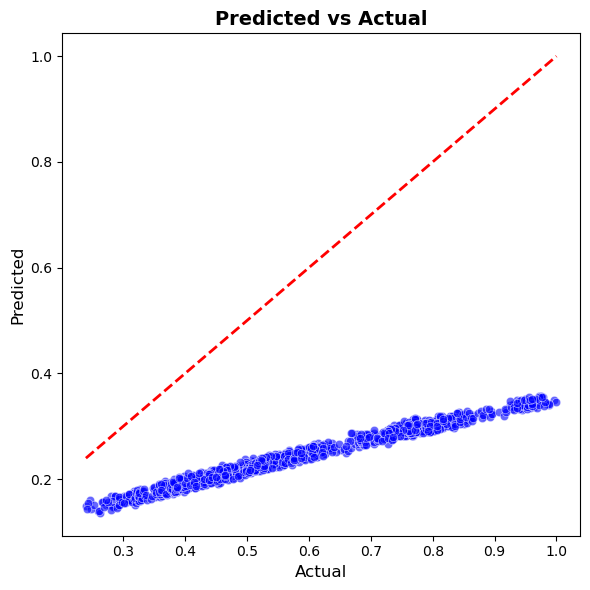


Epoch    24
Train_cost  = 0.0013 | Test_cost  = 0.1333 | Train_score = 0.5065 | Test_score = -3.0927 |
==> EarlyStop patience = 24 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 25 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1207.84it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0013 │  0.1285 │
│ MAE    │ 0.0240 │  0.3341 │
│ RMSE   │ 0.0352 │  0.3578 │
│ R2     │ 0.5246 │ -2.9471 │
└────────┴────────┴─────────┘

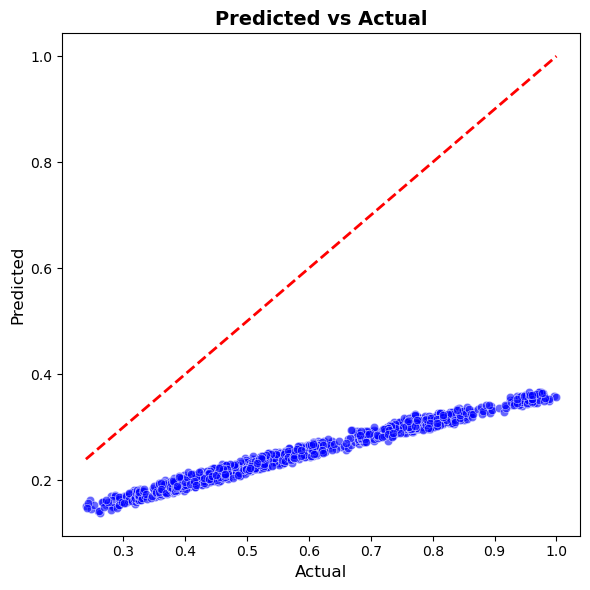


Epoch    25
Train_cost  = 0.0013 | Test_cost  = 0.1285 | Train_score = 0.5246 | Test_score = -2.9471 |
==> EarlyStop patience = 25 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 26 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1087.31it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0012 │  0.1239 │
│ MAE    │ 0.0235 │  0.3279 │
│ RMSE   │ 0.0346 │  0.3513 │
│ R2     │ 0.5422 │ -2.8052 │
└────────┴────────┴─────────┘

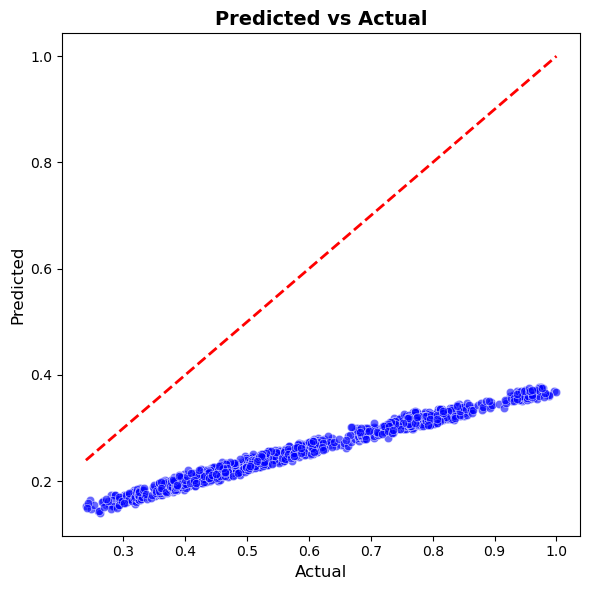


Epoch    26
Train_cost  = 0.0012 | Test_cost  = 0.1239 | Train_score = 0.5422 | Test_score = -2.8052 |
==> EarlyStop patience = 26 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 27 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1082.85it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0012 │  0.1194 │
│ MAE    │ 0.0231 │  0.3218 │
│ RMSE   │ 0.0339 │  0.3449 │
│ R2     │ 0.5593 │ -2.6669 │
└────────┴────────┴─────────┘

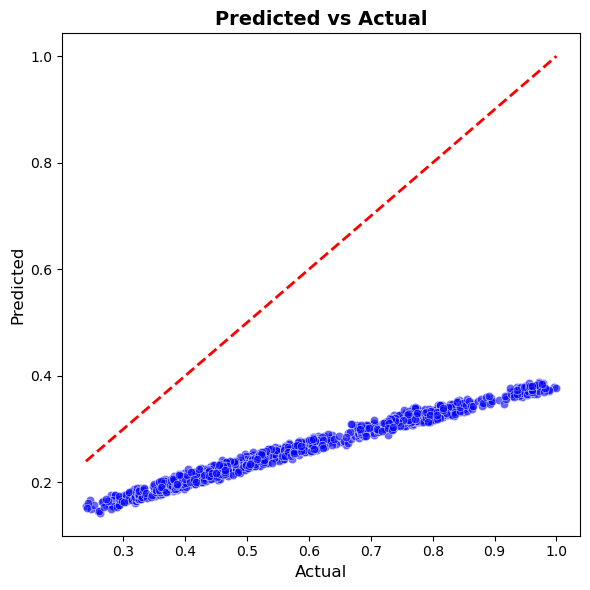


Epoch    27
Train_cost  = 0.0012 | Test_cost  = 0.1194 | Train_score = 0.5593 | Test_score = -2.6669 |
==> EarlyStop patience = 27 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 28 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1272.01it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0011 │  0.1150 │
│ MAE    │ 0.0227 │  0.3157 │
│ RMSE   │ 0.0333 │  0.3385 │
│ R2     │ 0.5760 │ -2.5322 │
└────────┴────────┴─────────┘

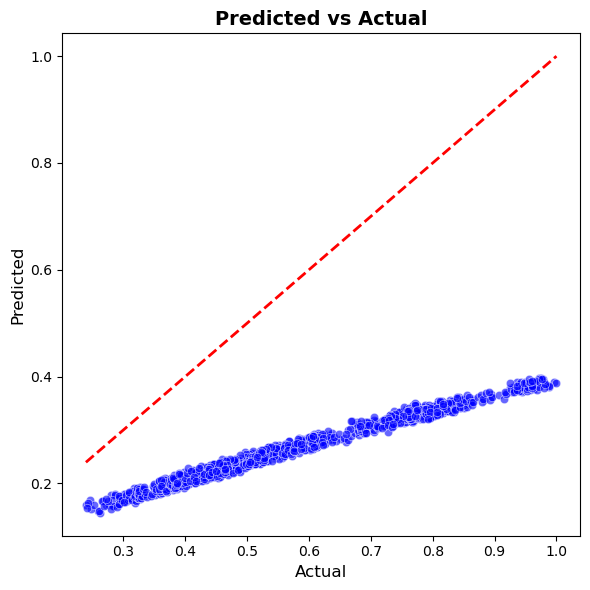


Epoch    28
Train_cost  = 0.0011 | Test_cost  = 0.1150 | Train_score = 0.5760 | Test_score = -2.5322 |
==> EarlyStop patience = 28 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 29 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1231.29it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0011 │  0.1108 │
│ MAE    │ 0.0222 │  0.3096 │
│ RMSE   │ 0.0326 │  0.3321 │
│ R2     │ 0.5923 │ -2.4010 │
└────────┴────────┴─────────┘

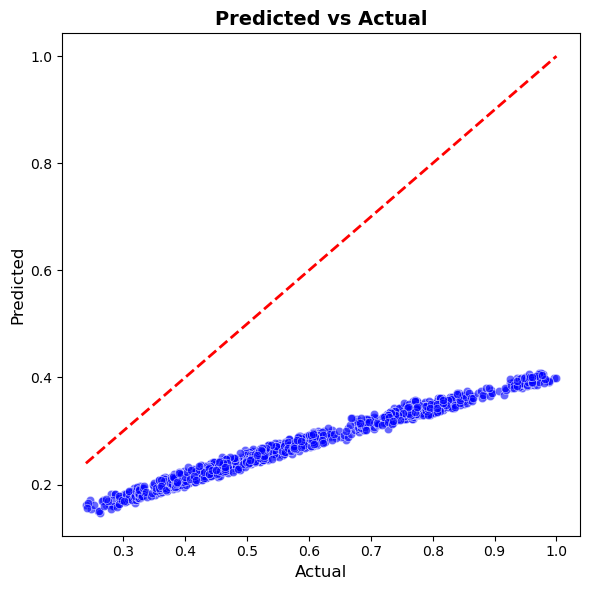


Epoch    29
Train_cost  = 0.0011 | Test_cost  = 0.1108 | Train_score = 0.5923 | Test_score = -2.4010 |
==> EarlyStop patience = 29 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 30 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1318.03it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃  Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │ 0.0010 │  0.1066 │
│ MAE    │ 0.0218 │  0.3036 │
│ RMSE   │ 0.0320 │  0.3258 │
│ R2     │ 0.6082 │ -2.2733 │
└────────┴────────┴─────────┘

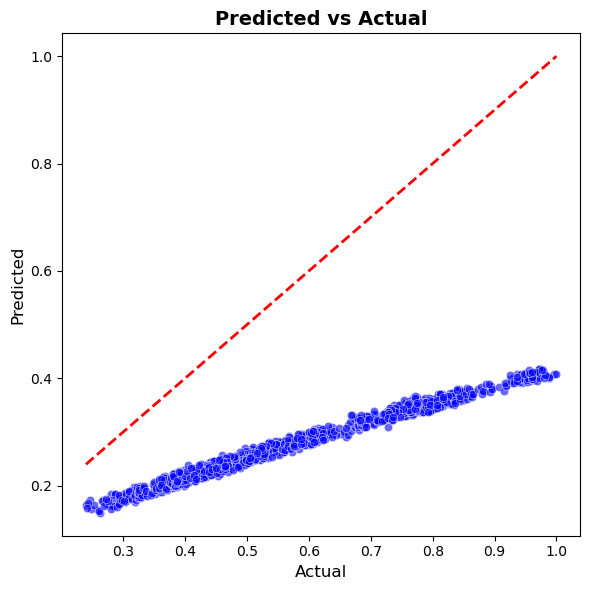


Epoch    30
Train_cost  = 0.0010 | Test_cost  = 0.1066 | Train_score = 0.6082 | Test_score = -2.2733 |
==> EarlyStop patience = 30 | Best test_score: 0.0000
==> Execute Early Stopping at epoch: 30 | Best test_score: 0.0000
==> Best model is saved at timeseris/regresi/rnn/microsoft_stock_data/


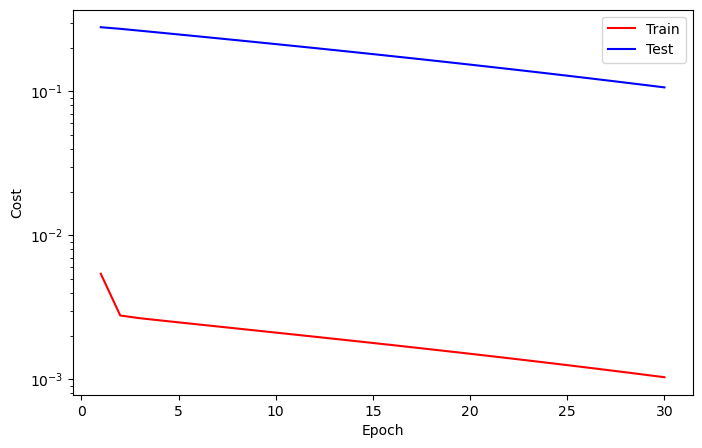

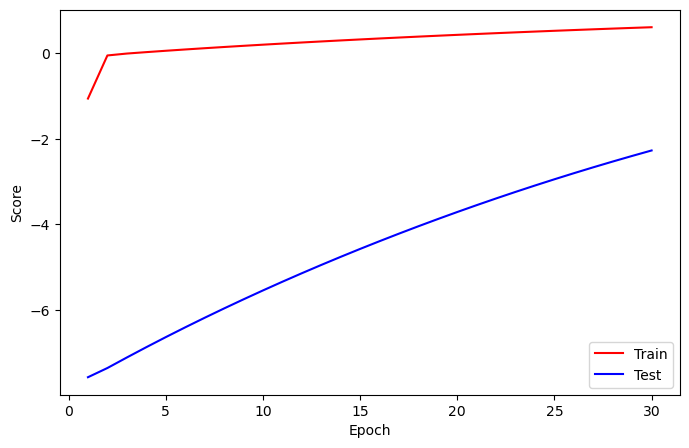

⏹️ Training dihentikan oleh early stopping.

In [40]:
from train_and_evaluate import train_and_evaluate_regression

train_and_evaluate_regression(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,         
    callback=callback
)

# Evaluate

📊 Evaluasi Model Regresi 
┏━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metrik        ┃  Nilai ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ 💥 Loss (avg) │ 0.0045 │
│ 📉 MAE        │ 0.0498 │
│ 📉 MSE        │ 0.0045 │
│ 📉 RMSE       │ 0.0668 │
│ 📈 R² Score   │ 0.8624 │
└───────────────┴────────┘

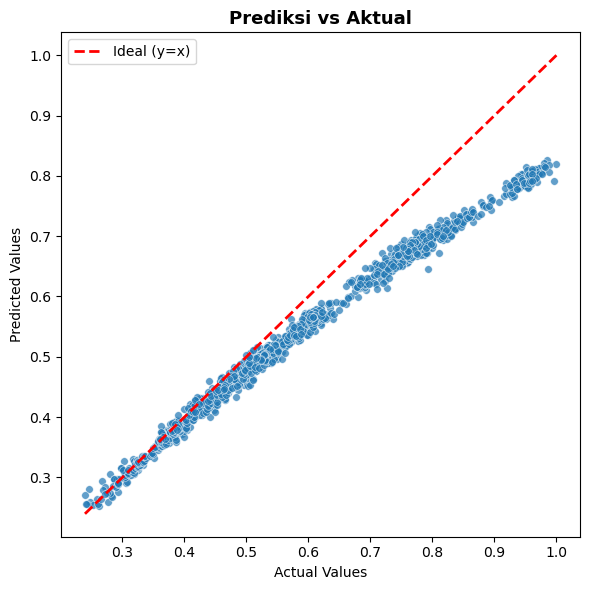

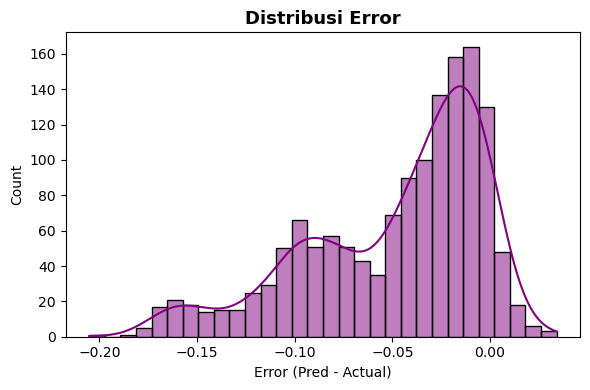

In [45]:
from evaluate import evaluate_regression
hsl = evaluate_regression(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
    dimension='1d'
)

In [46]:
hsl['df'].head(200)

,Target,Prediksi,Error,Error (%)
0,0.3010,0.2990,-0.0021,-0.69
1,0.3084,0.3021,-0.0063,-2.04
2,0.3187,0.3053,-0.0134,-4.20
3,0.3183,0.3095,-0.0088,-2.75
4,0.3249,0.3130,-0.0119,-3.66
...,...,...,...,...
195,0.3996,0.3772,-0.0224,-5.61
196,0.3900,0.3852,-0.0048,-1.24
197,0.3768,0.3892,0.0124,3.30
198,0.3867,0.3810,-0.0057,-1.48
